# Object Detection using YOLO on X-Ray Images of Luggage

Imports

In [1]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import numpy as np

import matplotlib.pyplot as plt
import cv2
import time

import yaml
import shutil
from PIL import Image

from ultralytics import YOLO
from IPython.display import Image as DisplayImage

In [3]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'x-ray-baggage-anomaly-detection' dataset.
Path to dataset files: /kaggle/input/x-ray-baggage-anomaly-detection


## Dataset Exploration

In [4]:
# check the contents of the path
print("Contents of dataset path:", os.listdir(path))

Contents of dataset path: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [5]:
# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# show the contents of the train path
print("Contents of train path:", os.listdir(train_path))

Contents of train path: ['labels', 'images']


In [6]:
# show the contents of the images and labels folders in the train path
print("Contents of train images path:", os.listdir(os.path.join(train_path, "images"))[:3])
print("Contents of train labels path:", os.listdir(os.path.join(train_path, "labels"))[:3])

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")

Contents of train images path: ['038952_jpg.rf.17662617dd2788b222a8367c70ab8da2.jpg', '039319_jpg.rf.53a7724c01403a8ddd5732e6233b71ba.jpg', '040081_jpg.rf.7caec84eb34cdbf9dbd1d18ec6476fd7.jpg']
Contents of train labels path: ['039520_jpg.rf.396eedf95df366636ff110958b26f15c.txt', '026395_jpg.rf.1e8b801dd52c1fdeb83c3a74f421655f.txt', '030601_jpg.rf.d1e8d92e612226304b6a46c2c695ac2b.txt']
Number of training images: 6181
Number of training labels: 6181


Each image has a corresponding txt file with the same name in the labels folder. Lets inspect one of the images and its corresponding label file.

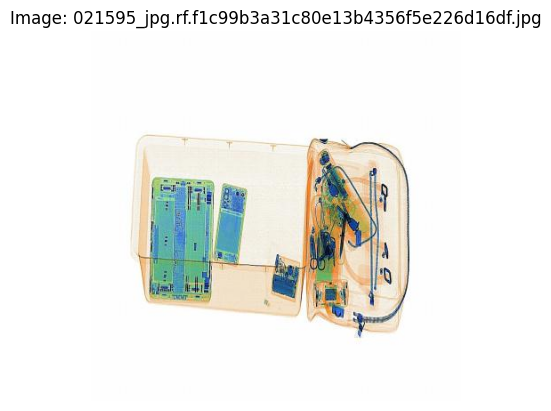

Contents of label file 021595_jpg.rf.f1c99b3a31c80e13b4356f5e226d16df.txt:
0 0.6862980769230769 0.5360576923076923 0.0673076923076923 0.18269230769230768


In [7]:
# select an image and its corresponding label file
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

# print the contents
print(f"Contents of label file {label_file}:\n{label_contents}")

Each label file contains 4 numbers corresponding to:
- class id
- center x coordinate of the bounding box (normalized by image width)
- center y coordinate of the bounding box (normalized by image height)
- width of the bounding box (normalized by image width)
- height of the bounding box (normalized by image height)

Let's visualize the bounding box on top of the image to better understand the format of the label files.

In [8]:
def draw_yolo_bbox(image_path, label_data):
    img = cv2.imread(image_path)
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    for line in label_data.splitlines():
        # extract data from label
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")

        # convert normalized coordinates to pixel values
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)

        # compute top-left and bottom-right corners of the bounding box
        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))

        # plot on top of the image (rectangle in red)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Objetos Prohibidos Detectados")
    plt.axis('off')
    plt.show()

Label data - x: 0.6862980769230769, y: 0.5360576923076923, w: 0.0673076923076923, h: 0.18269230769230768


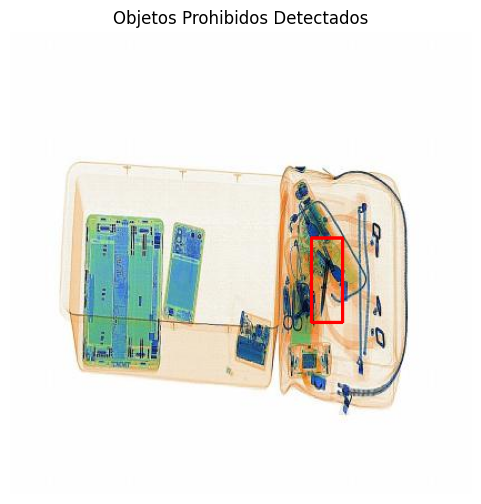

In [9]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)

In [10]:
# count the number of images in each set
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_val_images = len(os.listdir(os.path.join(val_path, "images")))
num_test_images = len(os.listdir(os.path.join(test_path, "images")))

print(f"Number of training images: {num_train_images}")
print(f"Number of validation images: {num_val_images}")
print(f"Number of test images: {num_test_images}")

Number of training images: 6181
Number of validation images: 1766
Number of test images: 883


In [11]:
# average number of objects per image in each set
def average_objects_per_image(label_path):
    total_objects = 0
    total_images = 0

    for label_file in os.listdir(label_path):
        with open(os.path.join(label_path, label_file), "r") as f:
            lines = f.readlines()
            total_objects += len(lines)
            total_images += 1

    return total_objects / total_images if total_images > 0 else 0

avg_objects_train = average_objects_per_image(os.path.join(train_path, "labels"))
avg_objects_val = average_objects_per_image(os.path.join(val_path, "labels"))
avg_objects_test = average_objects_per_image(os.path.join(test_path, "labels"))

print(f"Average number of objects per image in training set: {avg_objects_train:.2f}")
print(f"Average number of objects per image in validation set: {avg_objects_val:.2f}")
print(f"Average number of objects per image in test set: {avg_objects_test:.2f}")

Average number of objects per image in training set: 1.00
Average number of objects per image in validation set: 1.00
Average number of objects per image in test set: 1.00


In [12]:
# mean and std dev of image dimensions in each set
def average_image_dimensions(image_path):
    widths = []
    heights = []

    for image_file in os.listdir(image_path):
        img = cv2.imread(os.path.join(image_path, image_file))
        if img is not None:
            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)

    if not widths:
        return 0, 0, 0, 0

    # compute mean values
    avg_width = np.mean(widths)
    avg_height = np.mean(heights)

    # compute standard deviation values
    std_width = np.std(widths)
    std_height = np.std(heights)

    return avg_width, avg_height, std_width, std_height

In [13]:
avg_w_train, avg_h_train, std_w_train, std_h_train = average_image_dimensions(os.path.join(train_path, "images"))
avg_w_val, avg_h_val, std_w_val, std_h_val = average_image_dimensions(os.path.join(val_path, "images"))
avg_w_test, avg_h_test, std_w_test, std_h_test = average_image_dimensions(os.path.join(test_path, "images"))

print(f"Training set - Average width: {avg_w_train:.2f}, Average height: {avg_h_train:.2f}, Std width: {std_w_train:.2f}, Std height: {std_h_train:.2f}")
print(f"Validation set - Average width: {avg_w_val:.2f}, Average height: {avg_h_val:.2f}, Std width: {std_w_val:.2f}, Std height: {std_h_val:.2f}")
print(f"Test set - Average width: {avg_w_test:.2f}, Average height: {avg_h_test:.2f}, Std width: {std_w_test:.2f}, Std height: {std_h_test:.2f}")

Training set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Validation set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00
Test set - Average width: 416.00, Average height: 416.00, Std width: 0.00, Std height: 0.00


All images are sized 416x416 pixels and have at most one proihibited item.

## Image Preprocessing

In [14]:
def preprocess_xray(img):
    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # sharpening the image
    gaussian_blur = cv2.GaussianBlur(img_clahe, (9, 9), 10.0)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, gaussian_blur, -0.5, 0)

    return img_sharp

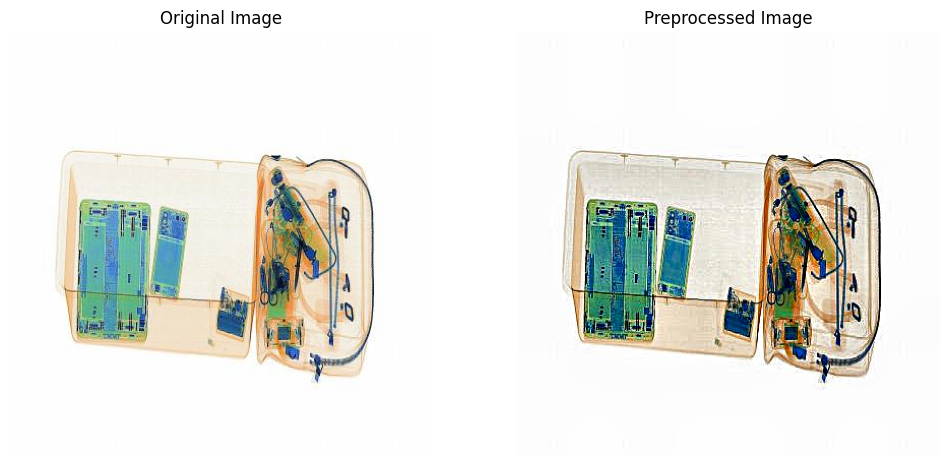

In [15]:
# plot original and preprocessed image side by side
original_img = cv2.imread(os.path.join(train_path, "images", image_file))
preprocessed_img = preprocess_xray(original_img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(preprocessed_img, cv2.COLOR_BGR2RGB))
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [18]:
path

'/kaggle/input/x-ray-baggage-anomaly-detection'

Apply the preprocessing function to all images in every dataset split.

In [20]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# apply to train, val and test
output_path = "/content/x-ray-baggage-anomaly-detection_processed"

train_images_proc = os.path.join(output_path, "train_processed", "images")
val_images_proc = os.path.join(output_path, "valid_processed", "images")
test_images_proc = os.path.join(output_path, "test_processed", "images")

print("Preprocessing images")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")

Preprocessing images
Preprocessing completed in 72.90 seconds


## YOLOv11s Model Training

Configure the yaml file. This initial configuration takes the default values for all parameters except for the number of classes and the paths to the training and validation datasets. We will use the default hyperparameters for training, which are optimized for small datasets.

In [23]:
data_config = {
    'train': train_images_proc.replace("/images", ""),
    'val': val_images_proc.replace("/images", ""),
    'test': test_images_proc.replace("/images", ""),
    'nc': 5,
    'names': ['0', '1', '2', '3', '4']
}

with open('xray_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

folder_mapping = {
    "train": "train_processed",
    "valid": "valid_processed",
    "test": "test_processed"
}

for orig_folder, dest_folder in folder_mapping.items():
    src_labels = os.path.join(path, orig_folder, "labels")
    dest_labels = os.path.join(output_path, dest_folder, "labels")
    shutil.copytree(src_labels, dest_labels, dirs_exist_ok=True)

In [ ]:
# Cargamos el modelo YOLOv11 small
model = YOLO('yolo11s.pt')

# Entrenamos
results = model.train(
    data='xray_data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    name='yolo11_xray_results',
    device="cuda",
    patience=10,
    hsv_h=0.015,  # ajuste de tono
    hsv_s=0.7,    # ajuste de saturación
    hsv_v=0.4,    # ajuste de brillo
    degrees=10.0, # rotación aleatoria
    translate=0.1,# traslación
    scale=0.5,    # escala
    flipud=0.0,   # flip vertical
    fliplr=0.5,   # flip horizontal
    mosaic=1.0    # técnica mosaic (muy útil en rayos x)
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xray_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_xray_results, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

In [ ]:
# display training curves and confusion matrix
results_path = 'runs/detect/yolo11_xray_results/'
DisplayImage(filename=f'{results_path}results.png', width=800)
DisplayImage(filename=f'{results_path}confusion_matrix.png', width=800)

# show metrics on test set
metrics = model.val(data='xray_data.yaml', split='test')

print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8.4±10.1 MB/s, size: 31.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/labels... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 532.1it/s 1.7s
val: New cache created: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 7.0it/s 8.0s
                   all        883        883      0.898      0.845      0.899      0.417
                     0        166        166      0.966      0.976      0.983      0.506
                     1        193        193      0.892      0.854      0.902      0.412
                     2   


image 1/883 /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/images/009008_jpg.rf.8f9d287571d5d48f46a87116a4a82d56.jpg: 416x416 1 3, 10.9ms
image 2/883 /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/images/009024_jpg.rf.6de3f50660b30e85323eb009190d7747.jpg: 416x416 1 2, 10.3ms
image 3/883 /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/images/009030_jpg.rf.c072eddbe5c4df12ba092a3fea353d7c.jpg: 416x416 1 2, 10.3ms
image 4/883 /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/images/009045_jpg.rf.73baf175ea33c52e85c53979fcc1cde0.jpg: 416x416 1 2, 10.9ms
image 5/883 /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1/test_processed/images/009072_jpg.rf.ee449c968c7fbd052f338148998aff10.jpg: 416x416 1 2, 16.3ms
image 6/883 /root/.cache/kagglehub/datasets/orvile/x-ray-ba

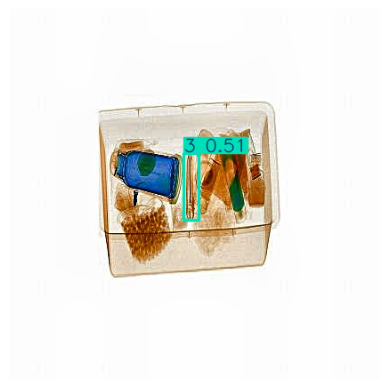

In [ ]:
# execute some predictions on test set
results_test = model.predict(source=test_images_proc, save=True, imgsz=416, conf=0.25)

# visualize a specific prediction
res = results_test[0].plot() # Dibuja las cajas predichas
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

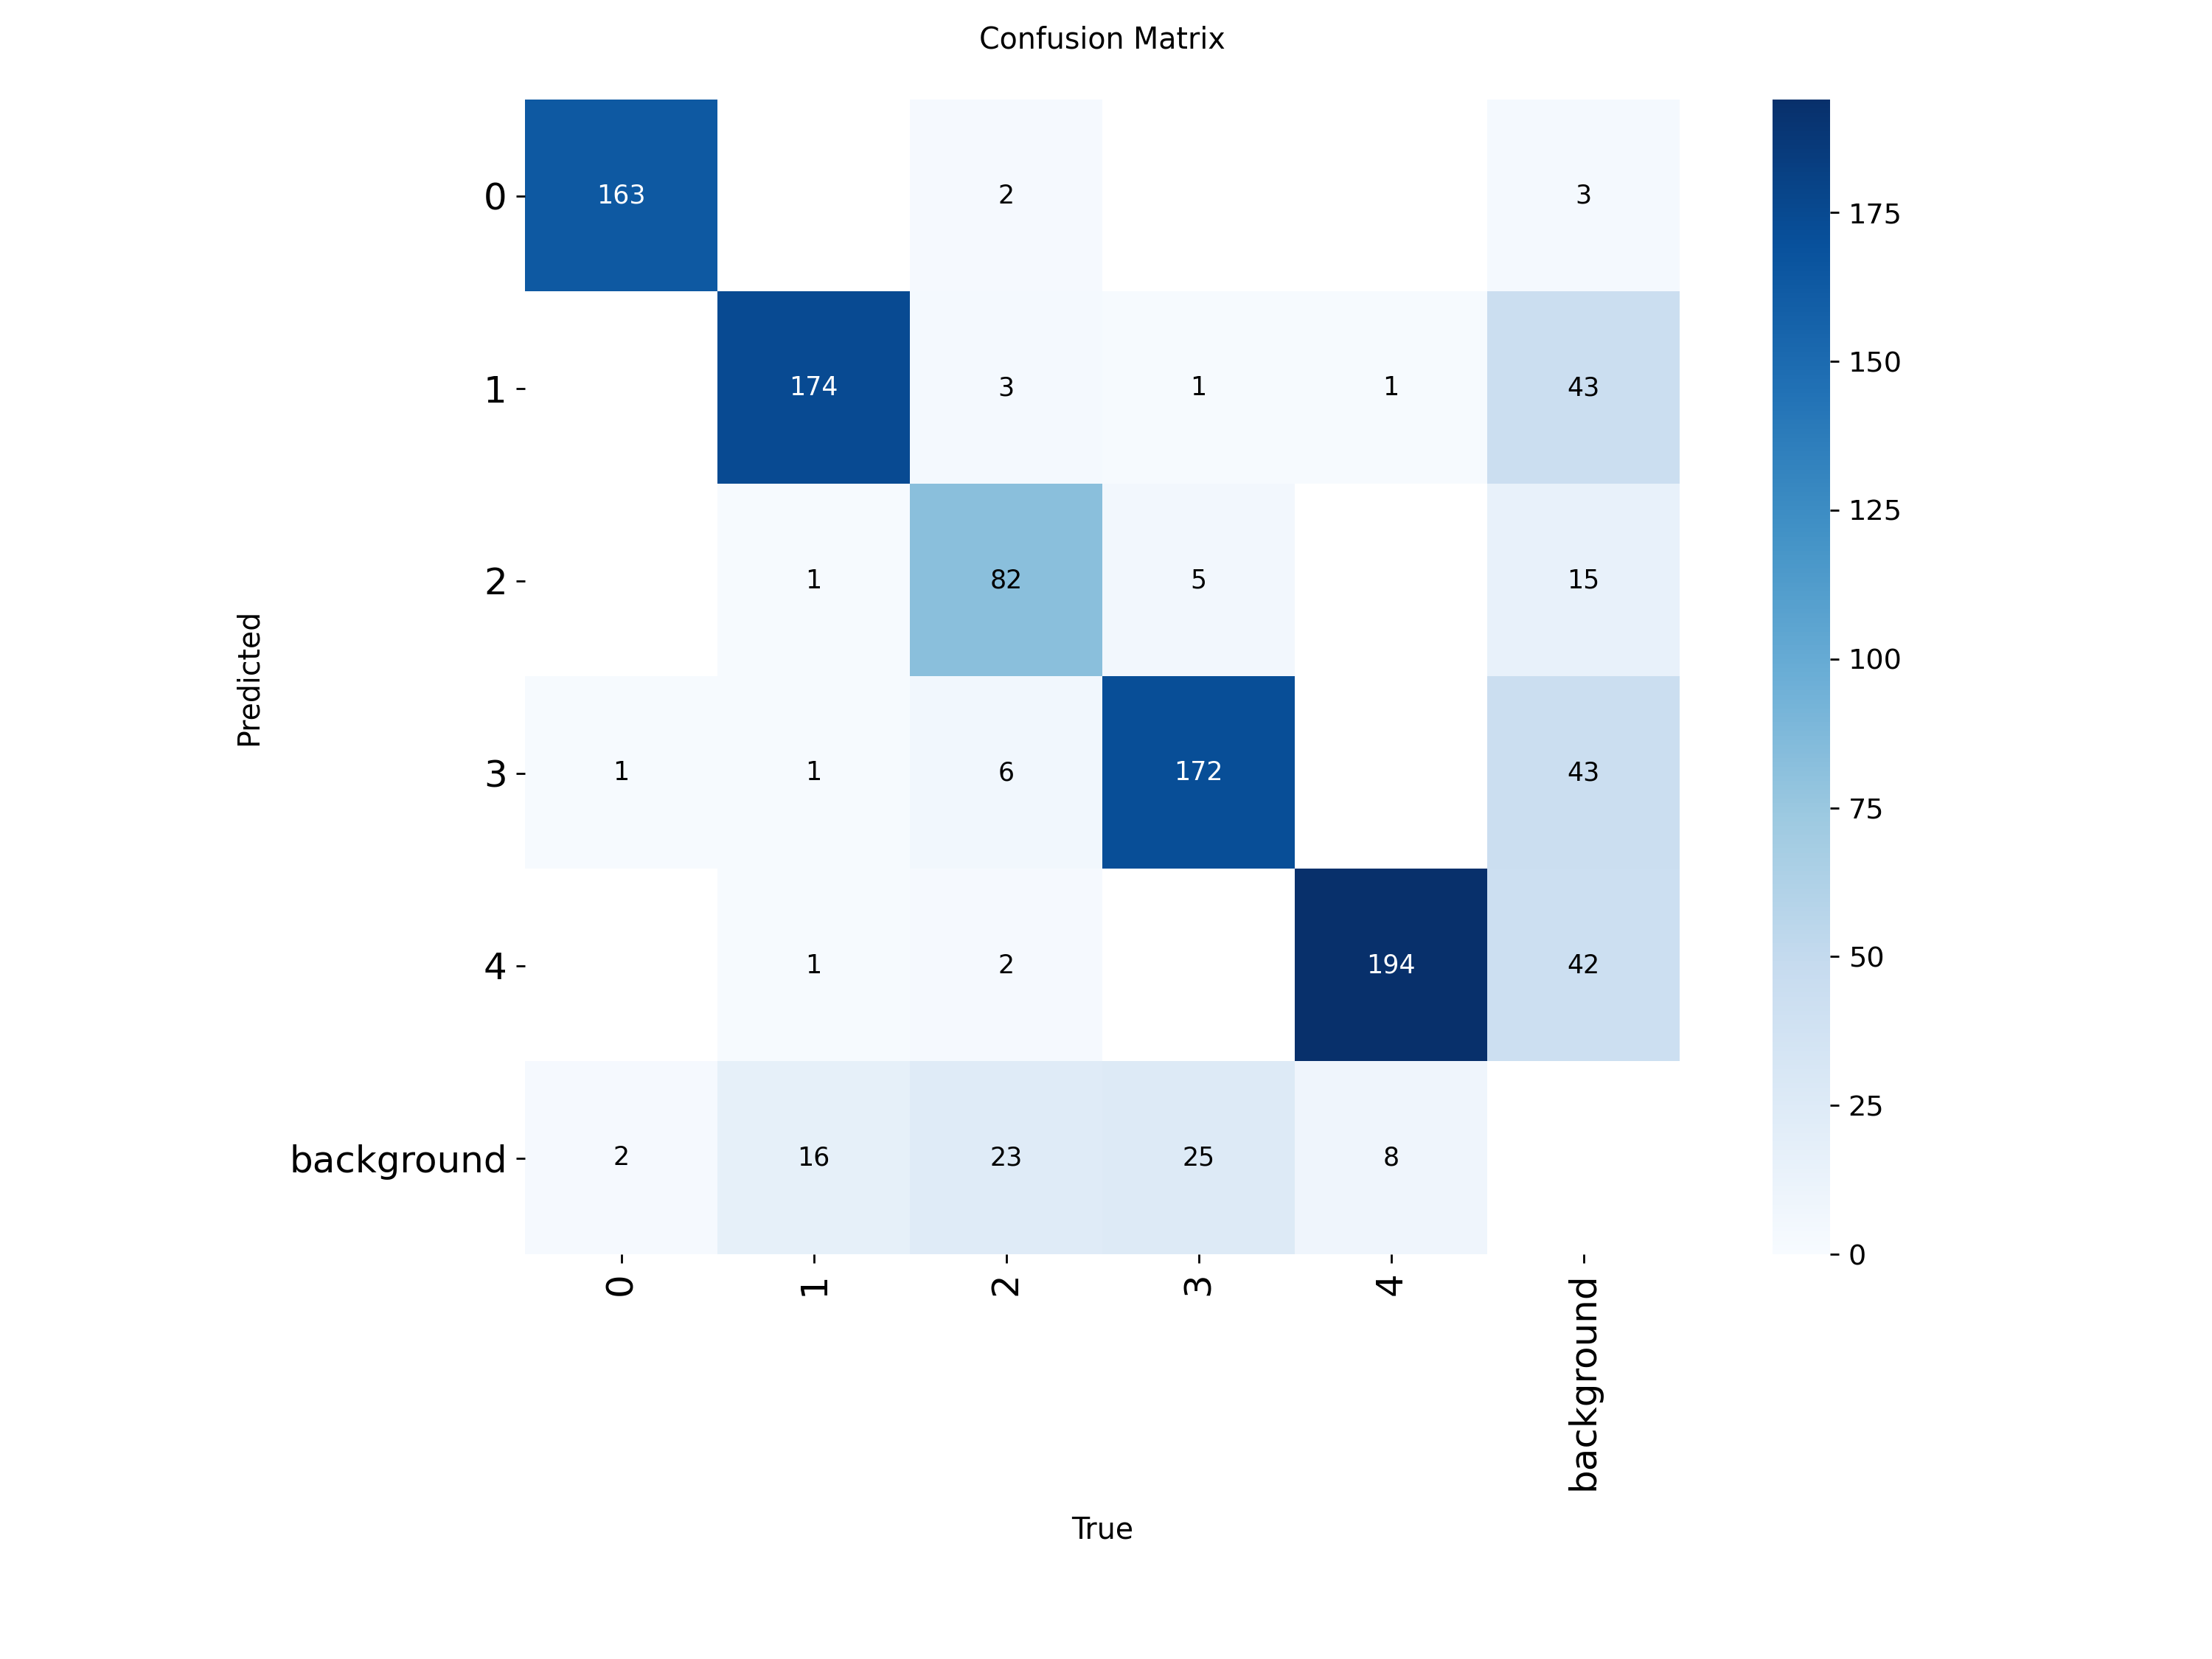

In [ ]:
# load confusion matrix image
DisplayImage(filename=f'runs/detect/val/confusion_matrix.png', width=800)

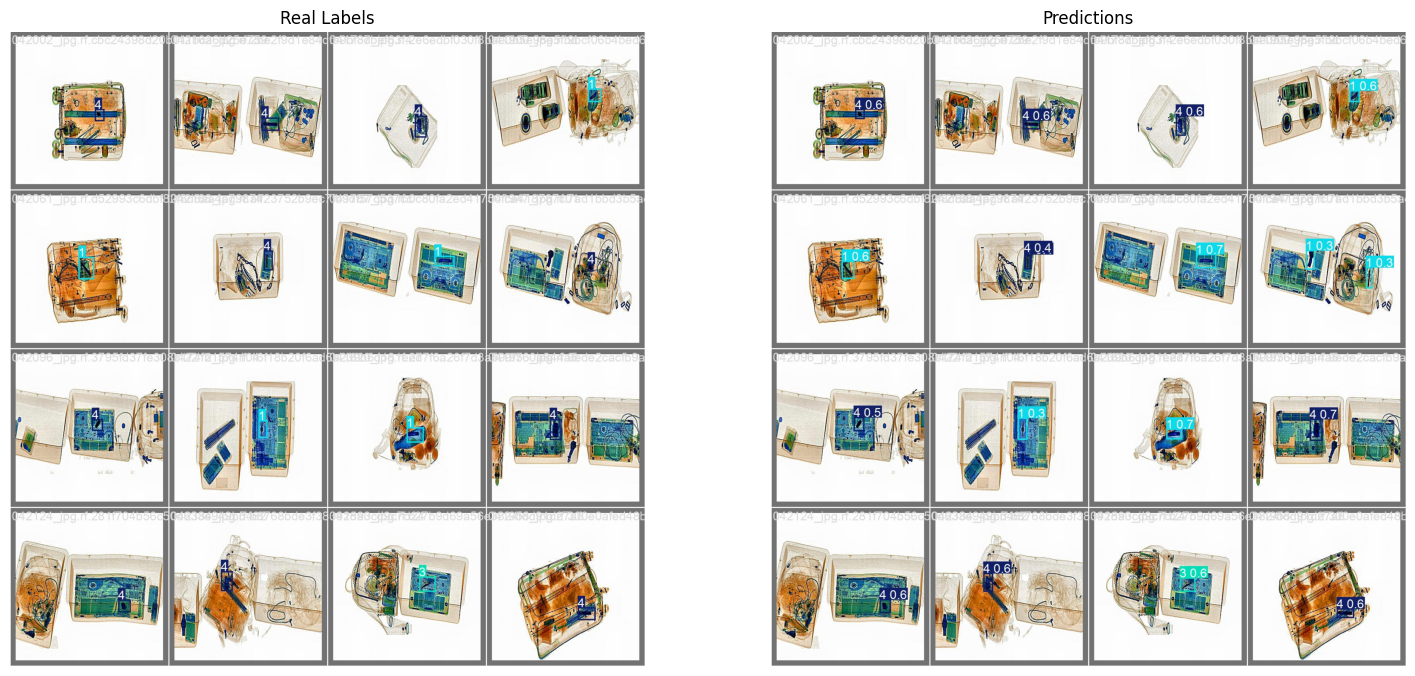

In [ ]:
# show some real labesls and predictions
batch0_real_labels_img_path = 'runs/detect/val/val_batch0_labels.jpg'
batch0_predictions_img_path = 'runs/detect/val/val_batch0_pred.jpg'

plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_real_labels_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Real Labels")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cv2.imread(batch0_predictions_img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB))
plt.title("Predictions")
plt.axis("off")
plt.show()

In [ ]:
# save the results folder as a zip file to download
folder_to_zip = 'runs'
output_filename = 'yolo_xray_results'

shutil.make_archive(output_filename, 'zip', folder_to_zip)

# YOLO v26 nano - train and evaluate

In [ ]:
# load the YOLOv26 nano model
model = YOLO('yolo26n.pt')

# train the model with the same parameters as before
results = model.train(
    data='xray_data.yaml',
    epochs=50,
    imgsz=416,
    batch=16,
    name='yolo26_xray_results',
    device="cuda",
    patience=10,
    hsv_h=0.015, # hue adjustment
    hsv_s=0.7, # saturation adjustment
    hsv_v=0.4, # brightness adjustment
    degrees=10.0, # random rotation
    translate=0.1, # translation
    scale=0.5, # scale
    flipud=0.0, # vertical flip
    fliplr=0.5, # horizontal flip
    mosaic=1.0 # mosaic technique (very useful in X-rays)
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xray_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_xray_results, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

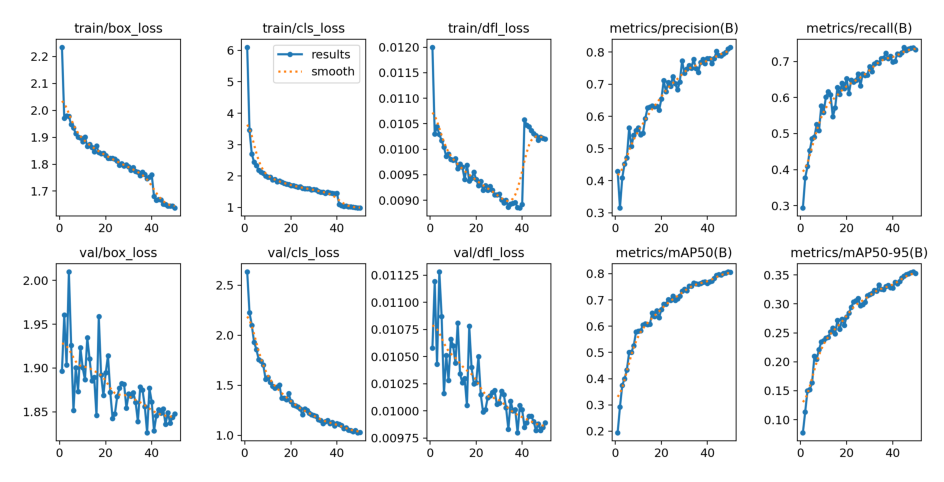

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1212.4±525.6 MB/s, size: 41.4 KB)
val: Scanning /content/x-ray-baggage-anomaly-detection_processed/test_processed/labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 284.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 9.3it/s 6.0s
                   all        883        883       0.82      0.748      0.817       0.38
                     0        166        166      0.934       0.97      0.979      0.504
                     1        193        193      0.768      0.798      0.826      0.372
                     2        118        118       0.82      0.415      0.597      0.245
                     3        203        203      0.775      0.695      0.777       0.37
                     4        203        203      0.802      0.862      0.907      0.

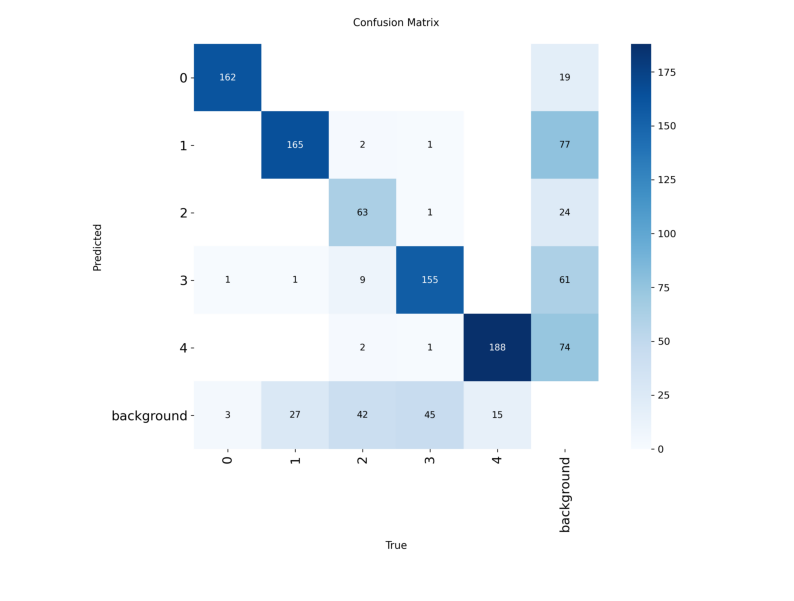

In [ ]:
# visualize training curves
results_path = 'runs/detect/yolo26_xray_results/'

plt.figure(figsize=(12, 6))
plt.imshow(plt.imread(os.path.join(results_path, 'results.png')))
plt.axis('off')
plt.show()

# evaluate on test set
metrics = model.val(data='xray_data.yaml', split='test')

# print metrics
print(f"\nMétricas en TEST:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# conf matrix
test_eval_path = metrics.save_dir
confusion_matrix_test_path = os.path.join(test_eval_path, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_test_path):
    plt.figure(figsize=(10, 10))
    plt.imshow(plt.imread(confusion_matrix_test_path))
    plt.axis('off')
    plt.show()
else:
    print(f"\n[Error] No se encontró la matriz en {confusion_matrix_test_path}. ")

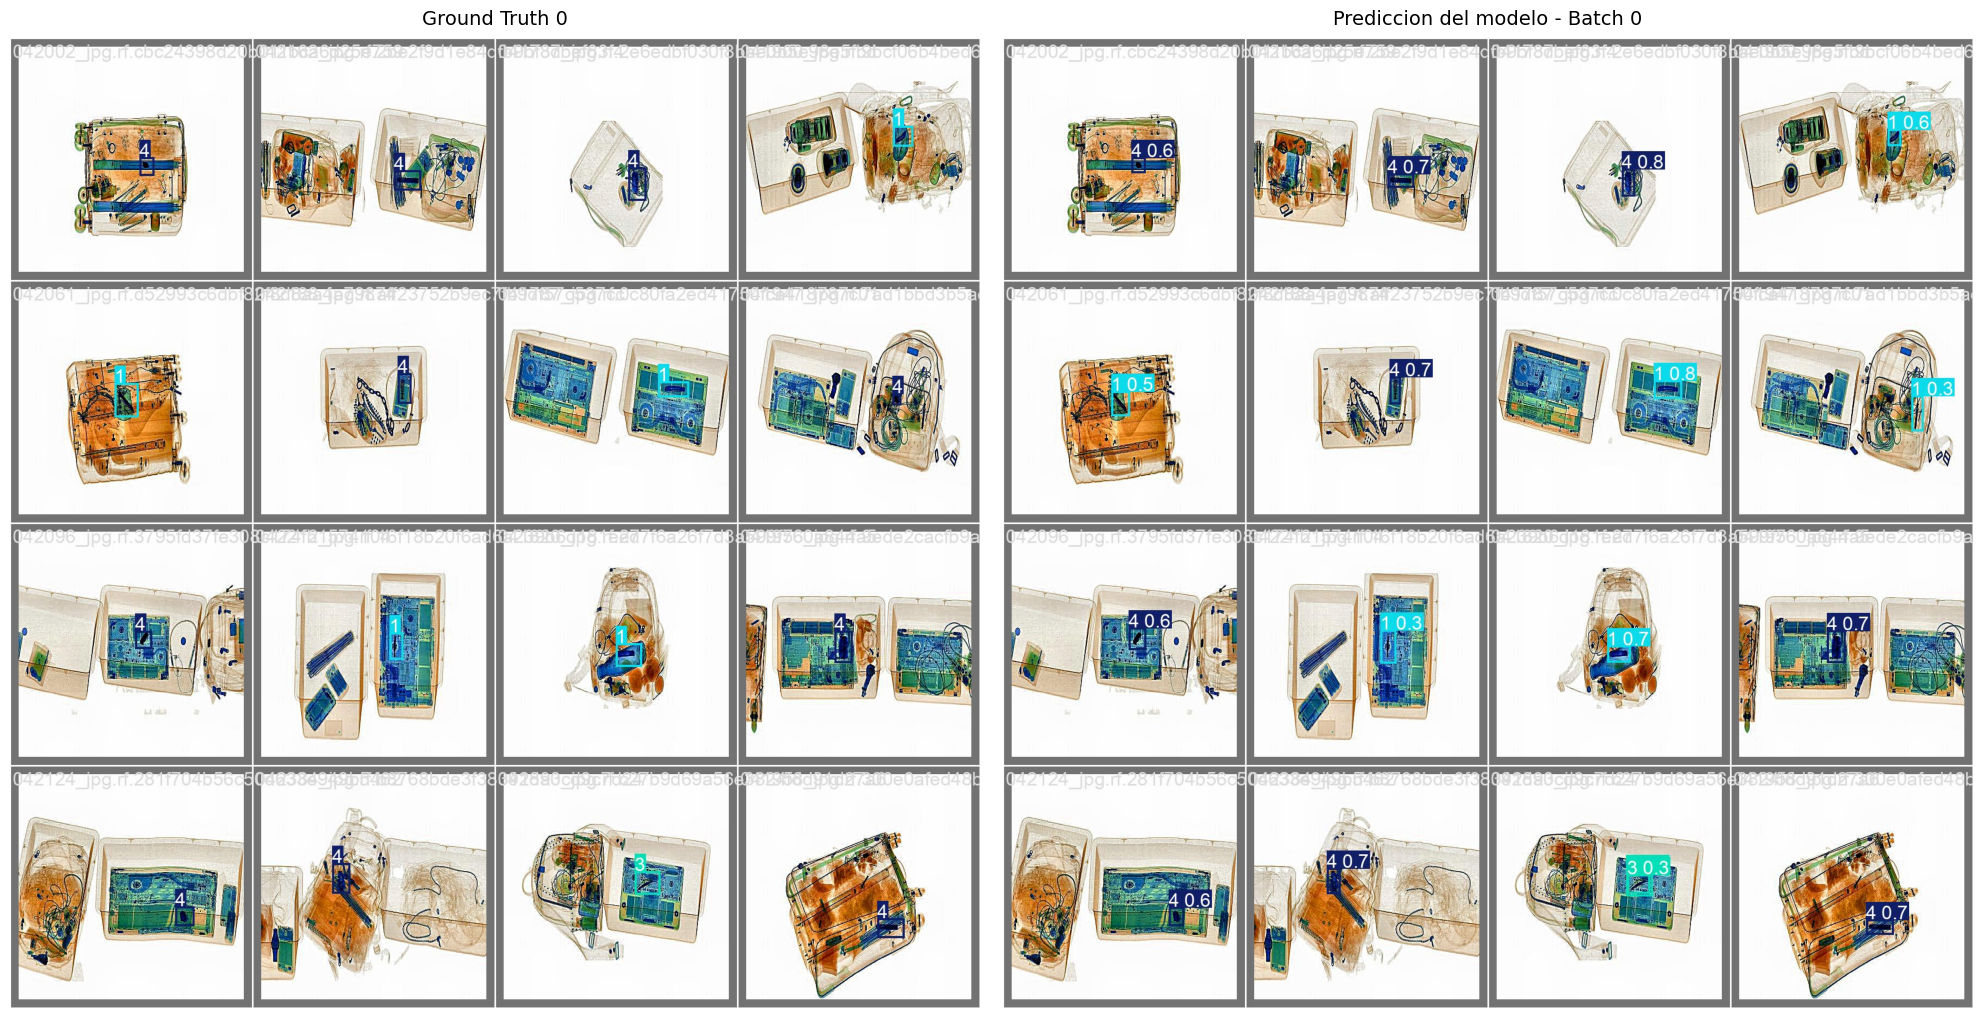

In [ ]:
# generate some predictions vs real labels for a batch of test images
batch_num = 0
img_labels_path = os.path.join(test_eval_path, f'val_batch{batch_num}_labels.jpg')
img_preds_path = os.path.join(test_eval_path, f'val_batch{batch_num}_pred.jpg')

# validate that the files exist before plotting
if os.path.exists(img_labels_path) and os.path.exists(img_preds_path):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # load and display ground truth
    img_labels = plt.imread(img_labels_path)
    axes[0].imshow(img_labels)
    axes[0].set_title(f"Ground Truth {batch_num}", fontsize=14, pad=10)
    axes[0].axis('off')

    # load and display predictions
    img_preds = plt.imread(img_preds_path)
    axes[1].imshow(img_preds)
    axes[1].set_title(f"Model Predictions - Batch {batch_num}", fontsize=14, pad=10)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No images found for batch {batch_num} in the results path.")

In [ ]:
# download from colab this best model to local (trained using colab)
from google.colab import files

best_model_path = 'runs/detect/yolo26_xray_results/weights/best.pt'

if os.path.exists(best_model_path):
    files.download(best_model_path)
else:
    print(f"File not found at {best_model_path}.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>